# Introduction au ML — Séance 9 (TP)
## Apprendre sans étiquettes : clustering et réduction de dimension

**Dr. El Hadji Bassirou TOURÉ** · DMI · FST · UCAD

***

Ce TP explore l'apprentissage **non-supervisé**. On code **k-means** à la main (NumPy) puis
on le confronte à scikit-learn ; on construit l'intuition de l'**ACP** (PCA) via la variance
et les vecteurs propres ; et l'on applique le tout à DataSANTÉ — avec un test révélateur :
le clustering, sans voir l'étiquette, retrouve-t-il le paludisme ?

**Durée estimée : 1h15.** Exécuter les cellules dans l'ordre.

## Partie 0 — Mise en place

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
print("Outils prêts.")

Outils prêts.


In [2]:
# Générateur officiel DataSANTÉ-221 (ne pas modifier)
def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1/(1+np.exp(-(-3 + 1.5*saison + 0.8*(fievre>38.5))))
    palu = (rng.uniform(0,1,n) < proba_palu).astype(int)
    return pd.DataFrame({'age':age,'glycemie':glycemie,'hemoglobine':hemoglobine,
                         'fievre':fievre,'saison':saison,
                         'duree_hospit_j':duree,'paludisme':palu})
df = generate_datasante221()
print("dimensions :", df.shape)

dimensions : (10000, 7)


## Partie 1 — La distance, fondation du clustering

Tout le non-supervisé repose sur une mesure de proximité : la distance euclidienne
(rappel Séance 4).

In [3]:
# Distance euclidienne entre deux points
def distance(p, q):
    return np.sqrt(np.sum((p - q)**2))

p = np.array([1.0, 2.0])
q = np.array([4.0, 6.0])
print(f"d(p, q) = sqrt((4-1)² + (6-2)²) = sqrt(9 + 16) = {distance(p, q):.1f}")

d(p, q) = sqrt((4-1)² + (6-2)²) = sqrt(9 + 16) = 5.0


**Lecture.** Le triangle 3-4-5 : un déplacement de 3 en horizontal, 4 en vertical, donne
une distance de 5. C'est le seul ingrédient géométrique dont k-means a besoin.

## Partie 2 — k-means, codé à la main

On code les deux étapes — affectation, mise à jour — et on déroule l'algorithme sur les
6 points du cours.

In [4]:
# Les 6 points du cours
P = np.array([[1.,1.], [2.,1.], [1.,2.], [5.,6.], [6.,5.], [6.,6.]])

def affecter(P, centres):
    # distance de chaque point à chaque centre, puis indice du plus proche
    D = np.sqrt(((P[:, None, :] - centres[None, :, :])**2).sum(axis=2))
    return D.argmin(axis=1)

def mettre_a_jour(P, labels, k):
    # chaque centre = moyenne des points de son cluster
    return np.array([P[labels == j].mean(axis=0) for j in range(k)])

def inertie(P, centres, labels):
    return sum(np.sum((P[i] - centres[labels[i]])**2) for i in range(len(P)))

print("points et fonctions prêts.")

points et fonctions prêts.


In [5]:
# Dérouler k-means depuis une initialisation médiocre
centres = np.array([[1., 1.], [2., 1.]])   # deux centres collés en bas
print(f"initialisation : {centres.tolist()}")

for it in range(1, 6):
    labels = affecter(P, centres)
    I = inertie(P, centres, labels)
    print(f"itération {it} : labels = {labels.tolist()}, inertie = {I:.3f}")
    nouveaux = mettre_a_jour(P, labels, k=2)
    if np.allclose(nouveaux, centres):
        print("  -> centres stables : convergence.")
        break
    centres = nouveaux

print(f"centres finaux : {centres.round(3).tolist()}")

initialisation : [[1.0, 1.0], [2.0, 1.0]]
itération 1 : labels = [0, 1, 0, 1, 1, 1], inertie = 108.000
itération 2 : labels = [0, 0, 0, 1, 1, 1], inertie = 9.688
itération 3 : labels = [0, 0, 0, 1, 1, 1], inertie = 2.667
  -> centres stables : convergence.
centres finaux : [[1.333, 1.333], [5.667, 5.667]]


**Lecture.** Partant de centres collés, k-means trouve les deux groupes en 3 itérations ;
l'inertie chute de 108 à 2,67. C'est la mesure que l'algorithme minimise à chaque étape.

In [6]:
# Confronter notre code à scikit-learn (mêmes centres initiaux)
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2, init=np.array([[1.,1.],[2.,1.]]), n_init=1, random_state=0).fit(P)
print(f"notre inertie   : {inertie(P, centres, affecter(P, centres)):.3f}")
print(f"sklearn inertie : {km.inertia_:.3f}")
print(f"centres sklearn : {km.cluster_centers_.round(3).tolist()}")
print("identiques — notre implémentation est correcte.")

notre inertie   : 2.667
sklearn inertie : 2.667
centres sklearn : [[1.333, 1.333], [5.667, 5.667]]
identiques — notre implémentation est correcte.


**Exercice.** Quatre points en 1D : `np.array([[1.],[2.],[8.],[9.]])`, avec `k=2` et
centres initiaux `[[1.],[2.]]`. Faire UNE affectation et UNE mise à jour avec nos fonctions,
et afficher les nouveaux centres.

In [ ]:
# Une étape de k-means sur les 4 points 1D

## Partie 3 — Combien de clusters ? Coude et silhouette

k-means exige de fixer k. Deux outils aident à le choisir.

In [8]:
from sklearn.metrics import silhouette_score

print(f"{'k':>3} {'inertie':>10} {'silhouette':>12}")
for k in range(1, 6):
    kk = KMeans(n_clusters=k, n_init=10, random_state=0).fit(P)
    if k >= 2:
        sil = silhouette_score(P, kk.labels_)
        print(f"{k:>3} {kk.inertia_:>10.3f} {sil:>12.4f}")
    else:
        print(f"{k:>3} {kk.inertia_:>10.3f} {'(indéfinie)':>12}")

  k    inertie   silhouette
  1     59.000  (indéfinie)
  2      2.667       0.8148
  3      1.833       0.4527
  4      1.000       0.0976
  5      0.500       0.0488


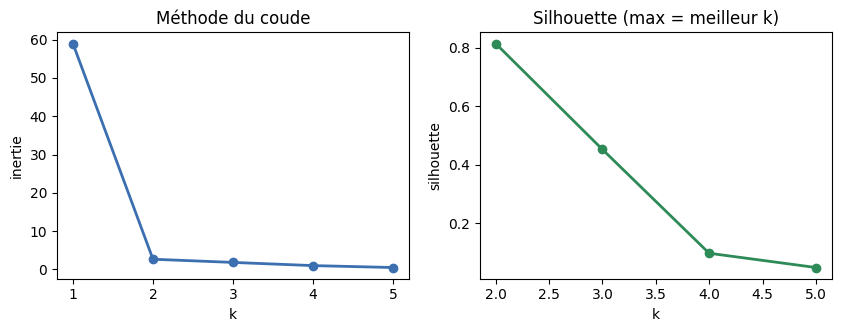

In [9]:
# Visualiser coude (inertie) et silhouette
ks = range(1, 6)
inerties = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(P).inertia_ for k in ks]
sils = [silhouette_score(P, KMeans(n_clusters=k, n_init=10, random_state=0).fit(P).labels_)
        if k >= 2 else np.nan for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(list(ks), inerties, "o-", color="#3b6fb0", lw=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertie"); axes[0].set_title("Méthode du coude")
axes[1].plot(list(ks)[1:], sils[1:], "o-", color="#2e8b57", lw=2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette"); axes[1].set_title("Silhouette (max = meilleur k)")
plt.show()

**Lecture.** Le coude et le maximum de silhouette désignent tous deux **k = 2** : les deux
outils convergent vers les deux groupes naturels.

## Partie 4 — Fondations de la PCA : variance, covariance, vecteurs propres

La réduction de dimension repose sur ces trois notions. Calculons-les.

In [10]:
# Variance d'une variable
x = np.array([2., 4., 6., 8.])
print(f"x = {x}, moyenne = {x.mean()}, variance = {x.var():.2f}")

# Covariance entre deux variables (b = 2a : varient parfaitement ensemble)
a = np.array([1., 2., 3., 4.])
b = np.array([2., 4., 6., 8.])
C = np.cov(a, b, bias=True)
print(f"\nmatrice de covariance de (a, b) :\n{C}")
print(f"cov(a, b) = {C[0,1]:.2f}  (positive : a et b montent ensemble)")

x = [2. 4. 6. 8.], moyenne = 5.0, variance = 5.00

matrice de covariance de (a, b) :
[[1.25 2.5 ]
 [2.5  5.  ]]
cov(a, b) = 2.50  (positive : a et b montent ensemble)


In [11]:
# Vecteurs et valeurs propres d'une matrice de covariance
Cov = np.array([[4., 2.], [2., 4.]])
valeurs, vecteurs = np.linalg.eigh(Cov)
ordre = np.argsort(valeurs)[::-1]          # de la plus grande à la plus petite
valeurs, vecteurs = valeurs[ordre], vecteurs[:, ordre]

print(f"valeurs propres : {valeurs}")
print(f"vecteur propre principal : {vecteurs[:,0].round(4)}  (~ diagonale)")
print(f"variance portée par PC1 : {valeurs[0]/valeurs.sum():.2%}")
# vérification A v = lambda v
print(f"\nvérif : Cov·v1 = {(Cov @ vecteurs[:,0]).round(4)}")
print(f"        lambda1·v1 = {(valeurs[0]*vecteurs[:,0]).round(4)}  -> identiques")

valeurs propres : [6. 2.]
vecteur propre principal : [0.7071 0.7071]  (~ diagonale)
variance portée par PC1 : 75.00%

vérif : Cov·v1 = [4.2426 4.2426]
        lambda1·v1 = [4.2426 4.2426]  -> identiques


**Lecture.** Les valeurs propres sont 6 et 2 ; le vecteur principal pointe la diagonale
(où les deux variables corrélées s'étalent ensemble) et porte 75 % de la variance. C'est
exactement ce que la PCA exploite.

## Partie 5 — L'ACP (PCA) sur DataSANTÉ

On standardise, on applique la PCA, et on choisit le nombre de composantes par la variance
expliquée cumulée.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feats = ['age','glycemie','hemoglobine','fievre','saison','duree_hospit_j']
X = StandardScaler().fit_transform(df[feats])   # standardisation OBLIGATOIRE

pca = PCA().fit(X)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
print("variance par composante :", evr.round(4))
print("variance cumulée        :", cum.round(4))
n80 = int(np.argmax(cum >= 0.80) + 1)
print(f"-> {n80} composantes suffisent pour 80 % de variance")

variance par composante : [0.3861 0.1739 0.1666 0.1486 0.0809 0.0439]
variance cumulée        : [0.3861 0.56   0.7266 0.8752 0.9561 1.    ]
-> 4 composantes suffisent pour 80 % de variance


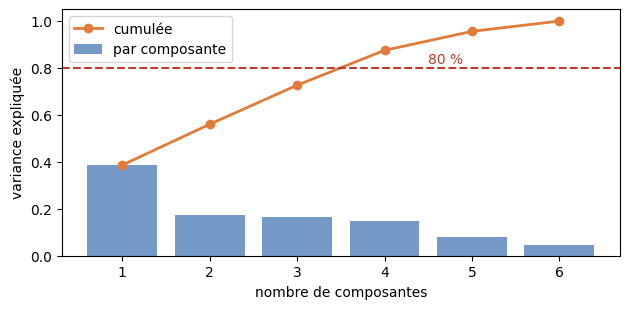

In [13]:
# Le scree plot : variance par composante et cumulée
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.bar(range(1, len(evr)+1), evr, color="#3b6fb0", alpha=0.7, label="par composante")
ax.plot(range(1, len(cum)+1), cum, "o-", color="#e07b39", lw=2, label="cumulée")
ax.axhline(0.8, color="#c0392b", ls="--"); ax.text(4.5, 0.82, "80 %", color="#c0392b")
ax.set_xlabel("nombre de composantes"); ax.set_ylabel("variance expliquée"); ax.legend()
plt.show()

variance conservée par 2 composantes : 56.00%


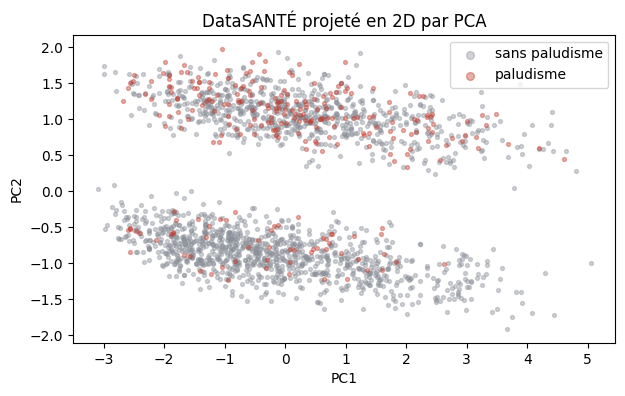

In [14]:
# Projeter en 2D pour visualiser (couleur = paludisme, NON utilisée pour la PCA)
proj = PCA(n_components=2).fit_transform(X)
print(f"variance conservée par 2 composantes : {PCA(n_components=2).fit(X).explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
idx = np.random.default_rng(0).choice(len(proj), 2000, replace=False)
for val, col, lab in [(0, "#8a8f98", "sans paludisme"), (1, "#c0392b", "paludisme")]:
    m = (df['paludisme'].values[idx] == val)
    ax.scatter(proj[idx][m, 0], proj[idx][m, 1], s=8, c=col, alpha=0.4, label=lab)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=2)
ax.set_title("DataSANTÉ projeté en 2D par PCA")
plt.show()

**Lecture.** Deux composantes conservent 56 % de la variance — assez pour une vue
d'ensemble. La couleur (paludisme) n'a pas servi à la projection : pourtant un gradient
apparaît, signe que la structure non-supervisée recoupe le diagnostic.

**Exercice.** Refaire une PCA en gardant assez de composantes pour **90 %** de variance
(`PCA(n_components=0.9)`), et afficher le nombre de composantes retenues (`pca.n_components_`).

In [ ]:
# PCA à 90 % de variance

## Partie 5ter — Pourquoi standardiser avant k-means

k-means repose sur la distance ; une variable à grande échelle écrase les autres.
Démontrons-le.

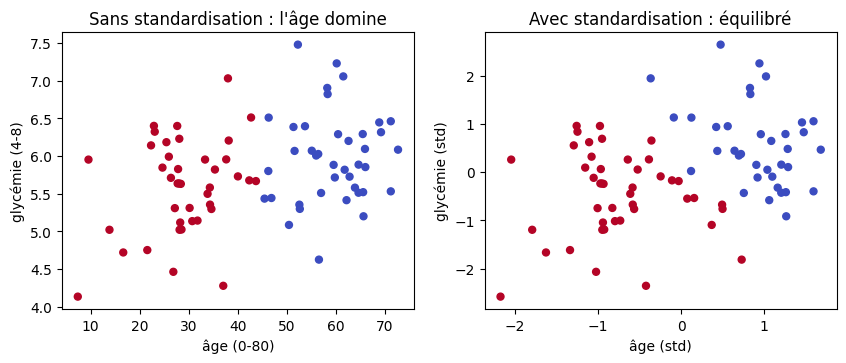

In [16]:
# Deux variables d'échelles très différentes : âge (0-80) et glycémie (4-8)
rng = np.random.default_rng(3)
age_d = np.concatenate([rng.normal(30, 8, 40), rng.normal(60, 8, 40)])
gly_d = np.concatenate([rng.normal(5.5, 0.6, 40), rng.normal(6.0, 0.6, 40)])
Xraw = np.column_stack([age_d, gly_d])

# clustering SANS standardisation vs AVEC
lab_raw = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xraw)
Xstd = StandardScaler().fit_transform(Xraw)
lab_std = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xstd)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(age_d, gly_d, c=lab_raw, cmap="coolwarm", s=25)
axes[0].set_xlabel("âge (0-80)"); axes[0].set_ylabel("glycémie (4-8)")
axes[0].set_title("Sans standardisation : l'âge domine")
axes[1].scatter(Xstd[:,0], Xstd[:,1], c=lab_std, cmap="coolwarm", s=25)
axes[1].set_xlabel("âge (std)"); axes[1].set_ylabel("glycémie (std)")
axes[1].set_title("Avec standardisation : équilibré")
plt.show()

**Lecture.** Sans standardisation, k-means sépare presque uniquement selon l'âge
(grande échelle) et ignore la glycémie. Après standardisation, les deux variables pèsent
également. La standardisation n'est pas optionnelle.

## Partie 5bis — Quand k-means échoue

k-means suppose des clusters ronds. Sur une structure non sphérique (deux lunes), il échoue.

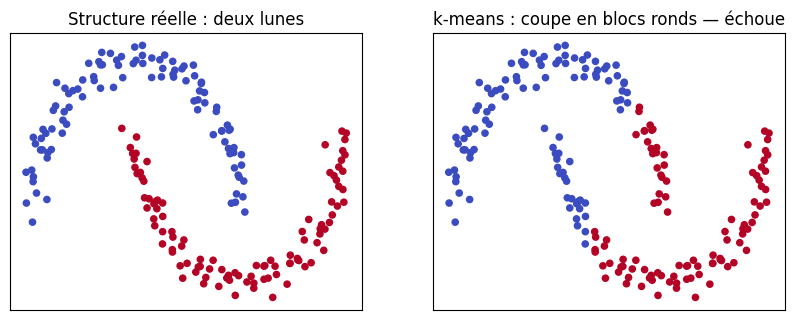

In [17]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=200, noise=0.06, random_state=0)
lab_m = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xm)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(Xm[:,0], Xm[:,1], c=ym, cmap="coolwarm", s=20)
axes[0].set_title("Structure réelle : deux lunes")
axes[1].scatter(Xm[:,0], Xm[:,1], c=lab_m, cmap="coolwarm", s=20)
axes[1].set_title("k-means : coupe en blocs ronds — échoue")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.show()

**Lecture.** k-means ne trace que des frontières droites entre centres : il découpe les
lunes à contresens. Pour des structures complexes, d'autres méthodes existent (DBSCAN,
clustering hiérarchique). Connaître cette limite, c'est savoir quand ne pas utiliser k-means.

## Mini-défi — Le clustering connaît-il le paludisme ?

Test décisif : on lance k-means **sans jamais lui montrer l'étiquette**, puis on regarde le
taux de paludisme par cluster.

In [18]:
# k-means sur 5 variables, sans l'étiquette paludisme
Xs = StandardScaler().fit_transform(df[['age','glycemie','hemoglobine','fievre','saison']])
km3 = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xs)
df['cluster'] = km3.labels_

print(f"taux de paludisme global : {df['paludisme'].mean()*100:.1f}%\n")
print(f"{'cluster':>8} {'n':>7} {'palu %':>8} {'pluies %':>10}")
for cl in sorted(df['cluster'].unique()):
    s = df[df['cluster'] == cl]
    print(f"{cl:>8} {len(s):>7} {s['paludisme'].mean()*100:>8.1f} {s['saison'].mean()*100:>10.0f}")

taux de paludisme global : 11.8%

 cluster       n   palu %   pluies %
       0    3998      5.2          0
       1    3446     20.5        100
       2    2556     10.4         39


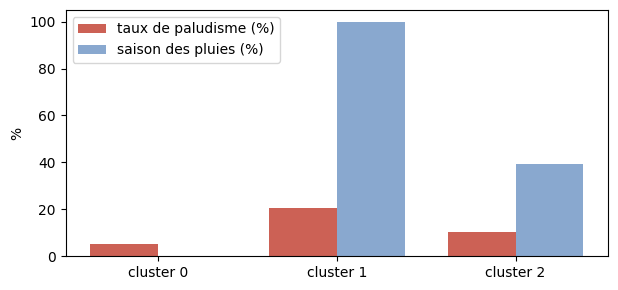

In [19]:
# Visualiser le taux de paludisme par cluster
taux = [df[df['cluster']==c]['paludisme'].mean()*100 for c in range(3)]
pluies = [df[df['cluster']==c]['saison'].mean()*100 for c in range(3)]
fig, ax = plt.subplots(figsize=(7, 3.2))
xp = np.arange(3); w = 0.38
ax.bar(xp - w/2, taux, w, color="#c0392b", alpha=0.8, label="taux de paludisme (%)")
ax.bar(xp + w/2, pluies, w, color="#3b6fb0", alpha=0.6, label="saison des pluies (%)")
ax.set_xticks(xp); ax.set_xticklabels([f"cluster {c}" for c in range(3)])
ax.set_ylabel("%"); ax.legend()
plt.show()

**Lecture — la leçon de la séance.** Sans avoir vu l'étiquette, k-means a formé des groupes
aux taux de paludisme très différents : le cluster « saison des pluies » (100 % de pluies)
atteint **20,5 %** de paludisme, contre **5,2 %** pour le cluster « saison sèche » — pour un
taux global de 11,8 %. Le clustering a retrouvé, seul, un facteur de risque majeur.

C'est toute la valeur du non-supervisé : faire émerger des structures réelles **avant** toute
annotation. Souvent la première étape d'un projet — comprendre la structure — avant de passer,
si besoin, au supervisé. La Séance 10 y revient justement, avec les réseaux de neurones.

## Synthèse — à compléter

1. Le **non-supervisé** cherche une structure **..........** étiquettes ; deux tâches :
   **..........** (regrouper) et **..........** (réduire la dimension).
2. **k-means** alterne **..........** (chaque point au centre le plus proche) et
   **..........** (chaque centre = moyenne de ses points), jusqu'à **..........**.
3. Il minimise l'**..........** ; on choisit k par le **..........** et la **..........**.
4. La **PCA** projette sur les directions de **..........** maximale, données par les
   **..........** de la matrice de **..........**.
5. On choisit le nombre de composantes par la **..........** cumulée.
6. Avant k-means comme avant la PCA, il faut toujours **..........** les variables.